# Netflix Data Analysis and Predictive Analytics Project

## Prepared By
- **Name:** Nadine Hassan                  **ID:** 231005869
- **Name:** Gannah Tamer                   **ID:** 231015206

## Supervised By
- **Dr.:** Salma

## University Information
- Arab Academy for Science, Technology & Maritime Transport  
- Faculty of Computer Science  
- Data Analysis Project  

## Dataset
Netflix Titles Dataset from Kaggle

## Project Objectives

This project analyzes the Netflix Titles dataset obtained from Kaggle.

The dataset contains information about movies and TV shows available on Netflix, including attributes such as title, director, cast, country, release year, rating, duration, and genre.

### Objectives of the Project

The main objectives of this project are:

- Understand the structure and characteristics of the Netflix dataset
- Perform data cleaning and preprocessing techniques
- Handle missing values and data inconsistencies
- Detect anomalies and outliers in numerical attributes
- Explore patterns and trends using data visualization
- Analyze relationships between Netflix content attributes
- Prepare the dataset for predictive analytics and machine learning models

### Import libraries and load dataset

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# Load Dataset
file_path = 'netflix_titles.csv'
df = pd.read_csv(file_path)
print("dataset loaded successfully")

dataset loaded successfully


## Data Understanding

show first 5 rows in our dataset

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


show last 5 rows in our dataset

In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8810,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
8811,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
8812,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
8813,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
8814,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...


## *Describe the dataset attributes**

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8815 entries, 0 to 8814
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8815 non-null   object
 1   type          8815 non-null   object
 2   title         8815 non-null   object
 3   director      6178 non-null   object
 4   cast          7987 non-null   object
 5   country       7979 non-null   object
 6   date_added    8805 non-null   object
 7   release_year  8815 non-null   int64 
 8   rating        8811 non-null   object
 9   duration      8812 non-null   object
 10  listed_in     8815 non-null   object
 11  description   8815 non-null   object
dtypes: int64(1), object(11)
memory usage: 826.5+ KB


In [6]:
# Display dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (8815, 12)


### Dataset Attributes Description

| Attribute | Description |
|---|---|
| show_id | Unique identifier for each Netflix title |
| type | Indicates whether the content is a Movie or TV Show |
| title | Name of the content |
| director | Director of the movie/show |
| cast | Main actors/actresses |
| country | Country of production |
| date_added | Date the content was added to Netflix |
| release_year | Original release year |
| rating | Audience maturity rating |
| duration | Movie duration or number of seasons |
| listed_in | Content genre/category |
| description | Short summary of the content |

In [7]:
# Display column names
print("Columns:")
print(df.columns)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [8]:
# Display statistical summary
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8815,8815,8815,6178,7987,7979,8805,8815.000000,8811,8812,8815,8815
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,2,6135,2,19,19,2820,109,NaN,3213,1796,363,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.186273,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.817619,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [9]:
# Check missing values
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2637
cast             828
country          836
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


## Data Preprocessing

Data preprocessing was applied to improve data quality and prepare the dataset for analysis and visualization.

The preprocessing steps included:
- Handling missing values
- Removing duplicates
- Converting data types
- Creating new features for analysis

### 1.Handle missing values

In [10]:
# Fill descriptive text columns with 'Unknown'
text_cols = ['director', 'cast', 'country']

for col in text_cols:
    df[col] = df[col].fillna('Unknown')

# Fill small categorical missing values with mode
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Clean date column
df['date_added'] = df['date_added'].str.strip() # Removes invisible whitespace characters from the start and end of the string.

# Converts the text string into a real Python datetime object.
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='%B %d, %Y',
    errors='coerce' #if any value can't be parsed, don't crash — just convert it to NaT (Not a Time), which is the datetime equivalent of NaN
)

# Fill missing dates with most frequent date
df['date_added'] = df['date_added'].fillna(
    df['date_added'].mode()[0]
)

2. Remove Duplicates

In [11]:
# Check total number of duplicate rows
print("Duplicates Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 8
Duplicates After: 0


3. Convert Data Types

In [12]:
df['rating'] = df['rating'].astype('category')
df['type'] = df['type'].astype('category')

4. Feature Engineering

In [13]:
# Extract year and month ,Why extract them? Machine learning models and most statistical functions cannot use a full datetime object directly — they need plain numbers.
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

# Extract numeric duration , Uses regex to pull out only the digits from the text string.
df['duration_num'] = df['duration'].str.extract(r'(\d+)')

df['duration_num'] = pd.to_numeric(df['duration_num']) #Converts the extracted string "90" into the actual number 90 so you can do math on it

# Fill missing duration with median
median_duration = df['duration_num'].median()

df['duration_num'] = df['duration_num'].fillna(median_duration)

Why separate movies at all? Because mixing movie durations (minutes) with TV show durations (seasons) in the same analysis creates meaningless statistics — comparing 90 minutes to 2 seasons is nonsensical.
This re-extracts duration specifically for movies only, so all values now represent pure minutes — no seasons mixed in. This is why the movies statistics are much cleaner and more meaningful than the full dataset.

In [14]:
# Create separate movie dataset
movies = df[df['type'] == 'Movie'].copy()

# Extract movie duration in minutes
movies['duration_num'] = movies['duration'].str.extract(r'(\d+)')

movies['duration_num'] = pd.to_numeric(
    movies['duration_num']
)

# Fill missing values with median
movies['duration_num'] = movies['duration_num'].fillna(
    movies['duration_num'].median()
)

The original `duration` column stored values as text strings 
(e.g., "90 min", "2 Seasons"), making it unusable for numerical 
analysis or machine learning.

After extracting the numeric values into `duration_num`, the original 
`duration` column was dropped to avoid redundancy and keep the dataset clean.

In [15]:
# Drop original duration column after extraction
df.drop(columns=['duration'], inplace=True)

### Observation

After separating movies from TV shows, the duration statistics became more meaningful because all values represent movie durations in minutes.

The average Netflix movie duration is approximately 100 minutes, with most movies ranging between 87 and 114 minutes.

The dataset also contains a few extremely short and extremely long movies, which were identified as outliers during anomaly detection.

In [16]:
print(movies[['release_year', 'duration_num']].describe())

       release_year  duration_num
count   6131.000000   6131.000000
mean    2013.121514     99.576415
std        9.678169     28.283691
min     1942.000000      3.000000
25%     2012.000000     87.000000
50%     2016.000000     98.000000
75%     2018.000000    114.000000
max     2021.000000    312.000000


5. Final Validation

In [17]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
listed_in       0
description     0
added_year      0
added_month     0
duration_num    0
dtype: int64


In [18]:
print(df.dtypes)

show_id                 object
type                  category
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                category
listed_in               object
description             object
added_year               int32
added_month              int32
duration_num           float64
dtype: object


## Anomaly Detection

Anomaly detection was applied to identify outliers in the dataset.

The `duration_num` attribute was selected because it is a numerical feature representing movie duration in minutes or number of seasons.

A boxplot visualization based on the Interquartile Range (IQR) method was used to detect unusually high or low duration values.

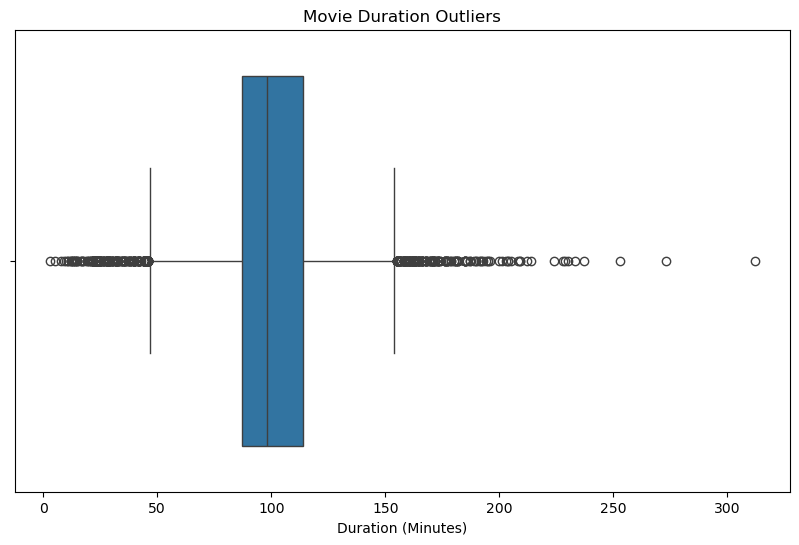

In [19]:
# Filter only movies
movies = df[df['type'] == 'Movie'].copy()

# Create boxplot
plt.figure(figsize=(10,6))

sns.boxplot(x=movies['duration_num'])

plt.title('Movie Duration Outliers')
plt.xlabel('Duration (Minutes)')

plt.show()

### Observation

The boxplot shows that most Netflix movie durations are concentrated between approximately 80 and 120 minutes, with a median close to 100 minutes.

Several outliers were detected outside the normal range:
- Very short movies below 50 minutes
- Very long movies above 155 minutes

These outliers represent unusual movie durations compared to the majority of the dataset. However, they may still correspond to valid Netflix content such as short films, documentaries, or extended editions.

In [20]:
# Calculate IQR
Q1 = movies['duration_num'].quantile(0.25)
Q3 = movies['duration_num'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Detect outliers
outliers = movies[
    (movies['duration_num'] < lower) |
    (movies['duration_num'] > upper)
]

print(outliers[['title', 'duration_num']].head())

                          title  duration_num
22              Avvai Shanmughi         161.0
24                        Jeans         166.0
45       My Heroes Were Cowboys          23.0
71  A StoryBots Space Adventure          13.0
73                 King of Boys         182.0


In [21]:
print("Number of outliers:", len(outliers))

Number of outliers: 450


In [22]:
outlier_percentage = (len(outliers) / len(movies)) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Percentage: 7.34%


### Outlier Analysis

The IQR-based anomaly detection method identified several movies with unusual durations compared to the majority of Netflix movies.

Examples include:
- Very short movies such as *A StoryBots Space Adventure* (13 minutes)
- Very long movies such as *King of Boys* (182 minutes)

These records were classified as statistical outliers because their durations fall outside the normal distribution range of the dataset.

However, these values may still represent valid Netflix content and were therefore retained in the dataset.

Standard deviation → affected by extreme outliers → distorted
IQR → only looks at middle 50% → outliers cannot affect it
→ IQR is "outlier-proof" by design

In [ ]:
# Calculate IQR
Q1 = movies['duration_num'].quantile(0.25)
Q3 = movies['duration_num'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR #lower = 87  - (1.5 × 27) = 87  - 40.5 = 46.5 minutes
# upper = 114 + (1.5 × 27) = 114 + 40.5 = 154.5 minutes
upper = Q3 + 1.5 * IQR

# Cap outliers
movies['duration_num'] = movies['duration_num'].clip(lower, upper)

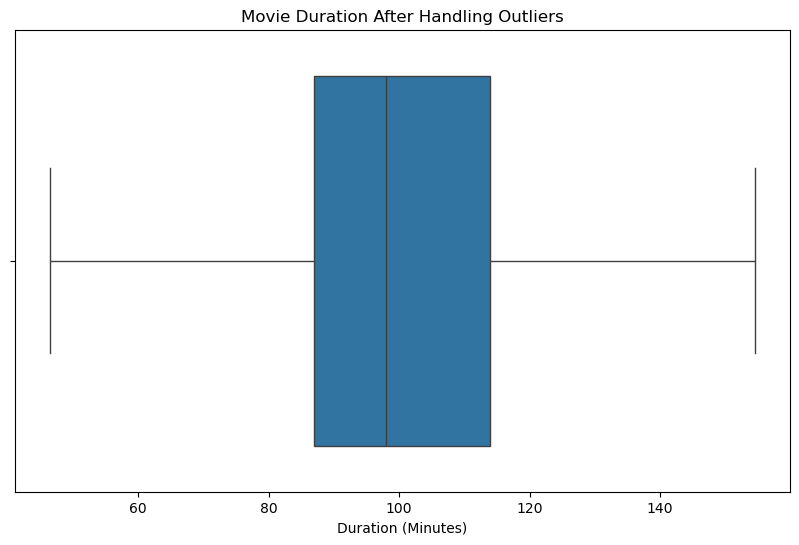

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(x=movies['duration_num'])

plt.title('Movie Duration After Handling Outliers')

plt.xlabel('Duration (Minutes)')

plt.show()

### Observation — After Outlier Handling

After applying IQR-based capping (winsorization):

- Minimum duration changed from 3 → 46.5 minutes
- Maximum duration changed from 312 → 154.5 minutes  
- Standard deviation reduced from 28.3 → 25.0, confirming 
  that extreme values were successfully bounded

The mean remained stable at ~99 minutes, indicating that 
capping only affected the extreme tails and did not distort 
the central distribution of the data.

The interquartile range (87–114 minutes) remained unchanged, 
confirming that the majority of Netflix movies have standard 
theatrical durations.

In [25]:
print(movies['duration_num'].describe())

count    6131.000000
mean       99.573316
std        25.012497
min        46.500000
25%        87.000000
50%        98.000000
75%       114.000000
max       154.500000
Name: duration_num, dtype: float64


### Data Quality Issue — Invalid Rating Values

During visualization, it was discovered that three values in the 
`rating` column contained duration strings instead of valid 
rating categories: `'66 min'`, `'74 min'`, and `'84 min'`.

These values represent a data entry error in the original Kaggle 
dataset, where movie duration values were accidentally stored in 
the rating column instead of the duration column.

**Handling approach:**
- These invalid entries were replaced with `NaN`
- The missing values were then filled using the column mode 
  (most frequent valid rating), consistent with the missing 
  value strategy applied earlier in preprocessing

This step ensures that the rating column contains only valid, 
meaningful audience classification labels.

In [26]:
# Step 1 — See the problem clearly
print("Unique ratings before cleaning:")
print(df['rating'].unique())

# Step 2 — Replace wrong values with NaN
import numpy as np

# These are duration values incorrectly stored as ratings
invalid_ratings = ['66 min', '74 min', '84 min']

df['rating'] = df['rating'].replace(invalid_ratings, np.nan)

# Step 3 — Fill the new NaNs with mode (same strategy as before)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Step 4 — Confirm they're gone
print("\nUnique ratings after cleaning:")
print(df['rating'].unique())
print("\nAny nulls?", df['rating'].isnull().sum())

Unique ratings before cleaning:
['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', ..., '84 min', '66 min', 'NR', 'TV-Y7-FV', 'UR']
Length: 17
Categories (17, object): ['66 min', '74 min', '84 min', 'G', ..., 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']

Unique ratings after cleaning:
['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', ..., 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR']
Length: 14
Categories (14, object): ['G', 'NC-17', 'NR', 'PG', ..., 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']

Any nulls? 0


/var/folders/s0/gcsz2sx55sv9xyzhh5bv_k2c0000gn/T/ipykernel_64456/1450694030.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['rating'] = df['rating'].replace(invalid_ratings, np.nan)


# Exploratory Data Analysis (EDA)

1. Summary Statistics

In [27]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,added_year,added_month,duration_num
count,8807,8807,8807,8807,8807,8807,8807,8807.000000,8807,8807,8807,8807.000000,8807.000000,8807.000000
unique,8807,2,8807,4529,7693,749,NaN,NaN,14,514,8775,NaN,NaN,NaN
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,NaN,NaN,TV-MA,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,NaN,NaN
freq,1,6131,1,2634,825,2818,NaN,NaN,3214,362,4,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 12:13:09.735437824,2014.180198,NaN,NaN,NaN,2018.873169,6.648575,69.853071
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,2008.000000,1.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,2018.000000,4.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-04 00:00:00,2017.000000,NaN,NaN,NaN,2019.000000,7.000000,88.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-18 00:00:00,2019.000000,NaN,NaN,NaN,2020.000000,10.000000,106.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,2021.000000,12.000000,312.000000


### 2. Distribution Analysis

Visualization 1 — Bar Chart: Average Duration by Rating

/var/folders/s0/gcsz2sx55sv9xyzhh5bv_k2c0000gn/T/ipykernel_64456/570134274.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating')['duration_num'].mean().sort_values().plot(


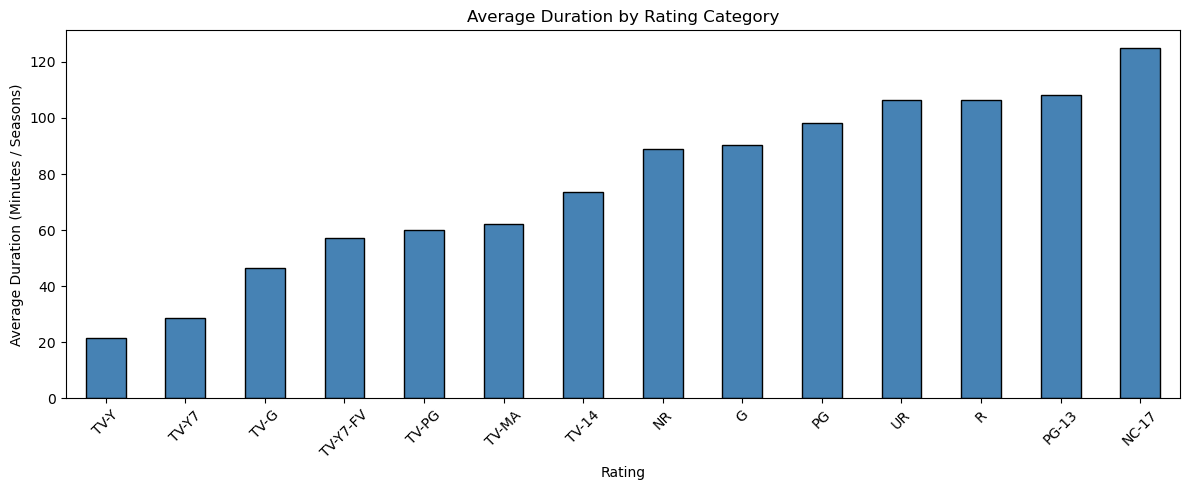

In [28]:
plt.figure(figsize=(12, 5))

df.groupby('rating')['duration_num'].mean().sort_values().plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Average Duration by Rating Category')
plt.xlabel('Rating')
plt.ylabel('Average Duration (Minutes / Seasons)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The bar chart reveals meaningful differences in average duration 
across rating categories:

- Content rated for **general audiences** (TV-G, TV-Y) tends to 
  have shorter durations, which aligns with the expectation that 
  children's content is typically briefer.

- Content rated **TV-MA and R** — targeting mature audiences — 
  tends to have higher average durations, suggesting that adult 
  content on Netflix is generally longer.

- Some rating categories show unusually high averages, which may 
  be influenced by the mix of Movies and TV Shows within each 
  rating group, since TV Show durations are measured in seasons 
  rather than minutes.

This visualization demonstrates that rating category carries 
information about content length, further supporting its use as 
a feature in predictive models.

### Visualization 2 — Histogram of Release Year

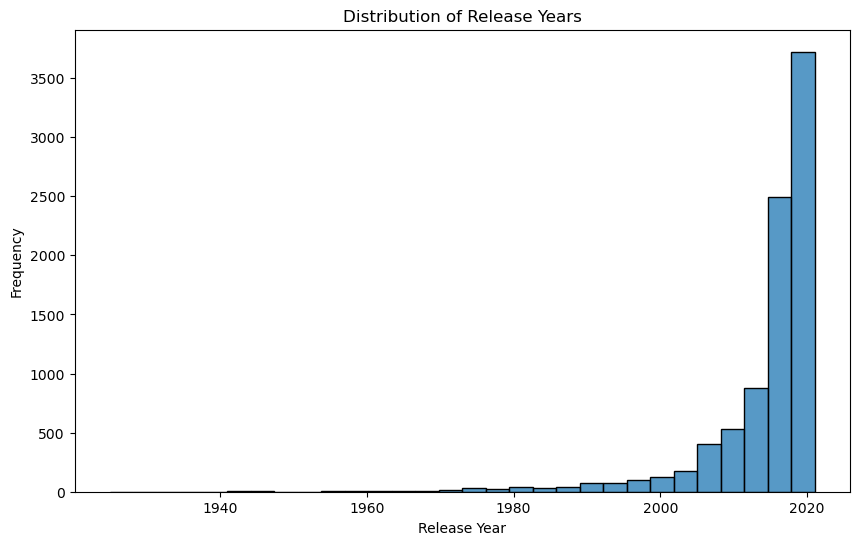

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(df['release_year'], bins=30)

plt.title('Distribution of Release Years')

plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

### Observation

Most Netflix content was released after the year 2000, with a strong increase in content production during recent years.

### Visualization 3 — Distribution of Movie Duration

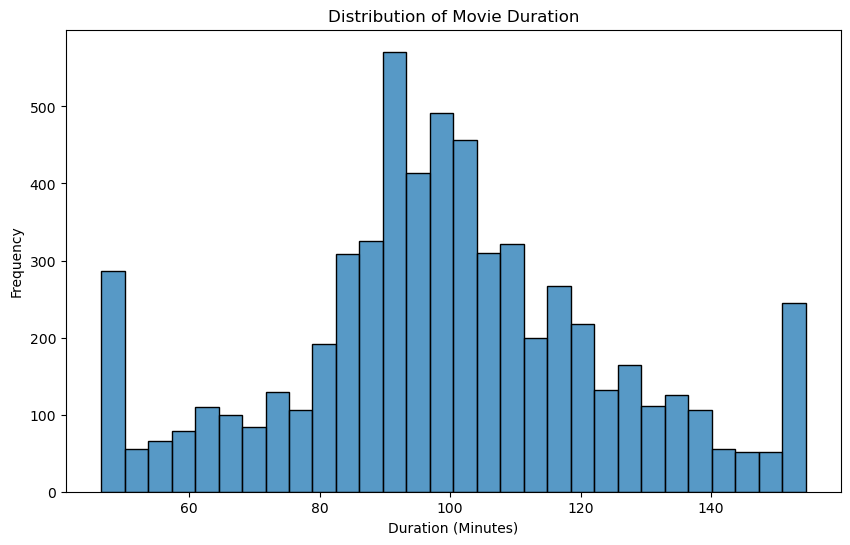

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(movies['duration_num'], bins=30)

plt.title('Distribution of Movie Duration')

plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')

plt.show()

### Observation

Most Netflix movies have durations between 80 and 120 minutes, which represents the standard length for movies.

### Visualization 4 — Top 10 Countries

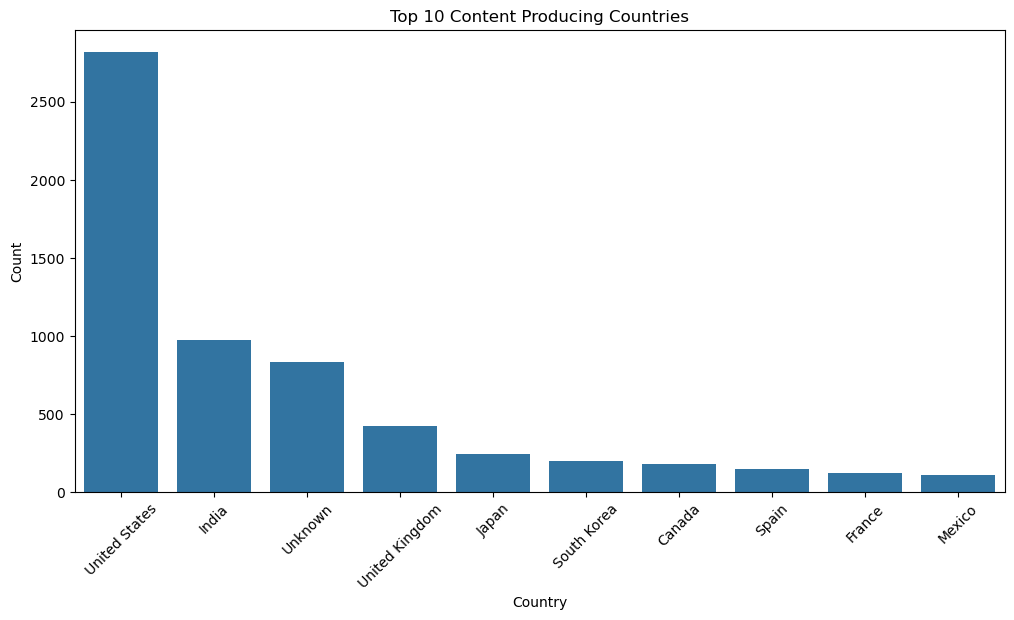

In [31]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top 10 Content Producing Countries')

plt.xticks(rotation=45)

plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

### Observation

The United States contributes the highest amount of Netflix content, followed by several other countries with significantly smaller contributions.

### Visualization 5 — Top Ratings

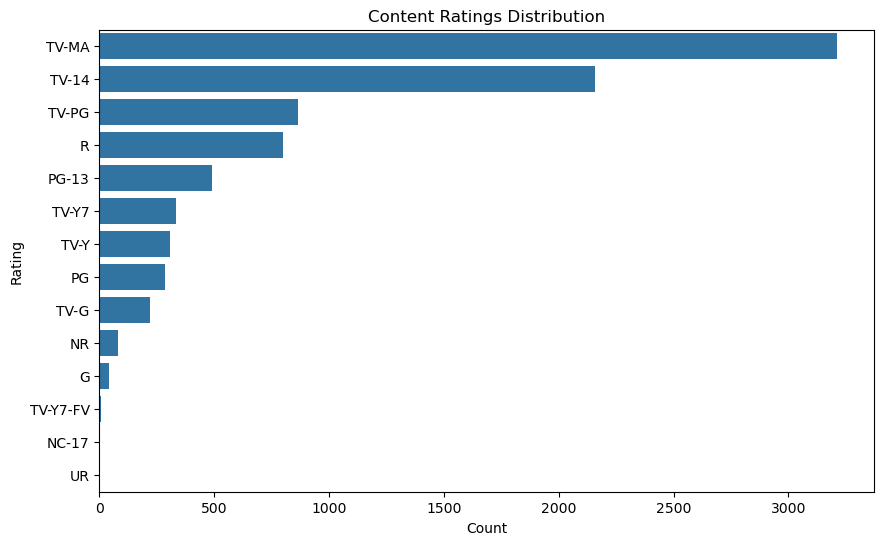

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title('Content Ratings Distribution')

plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

### Observation

TV-MA is the most common rating in the dataset, suggesting that Netflix contains a large amount of mature audience content.

### Visualization 6 — Content Added Over Years

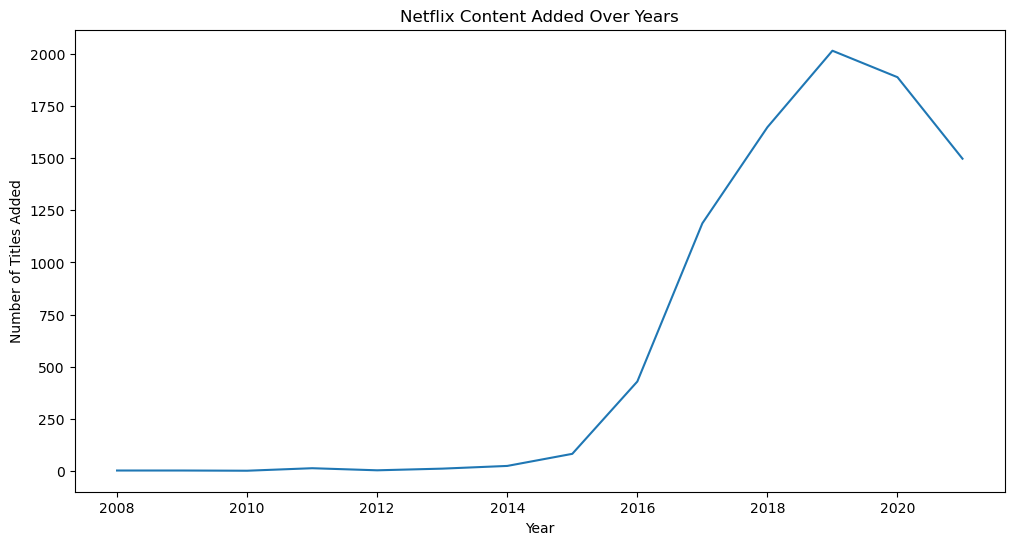

In [33]:
content_by_year = df['added_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    content_by_year.index,
    content_by_year.values
)

plt.title('Netflix Content Added Over Years')

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.show()

### Observation

Netflix content additions increased significantly after 2015, showing the platform's rapid growth in content production and acquisition.

# Data Visualization

### 6. Pie Chart — Content Type Distribution

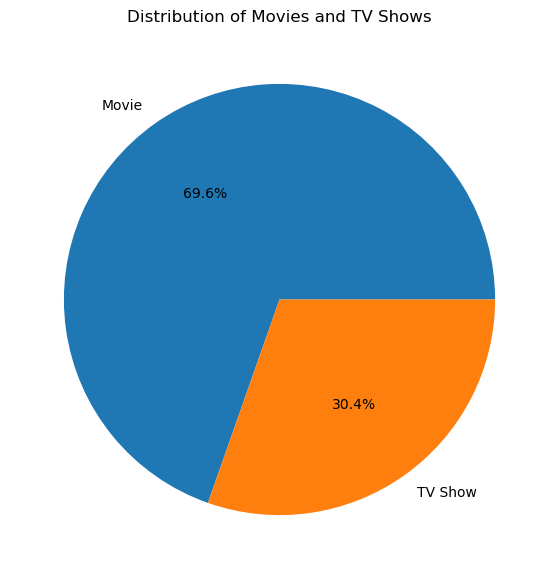

In [34]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Movies and TV Shows')

plt.show()

### Observation

Movies represent the majority of Netflix content, while TV Shows occupy a smaller proportion of the dataset.

### 7. Heatmap — Correlation Matrix

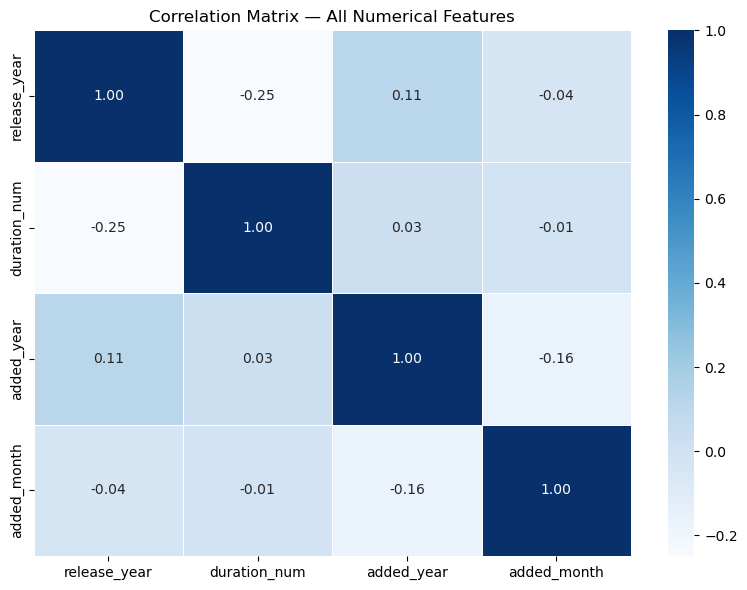

In [35]:
# Select all numeric columns from full dataset
heatmap_cols = df[['release_year', 'duration_num', 
                    'added_year', 'added_month']]

plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_cols.corr(), #calculates correlation coefficients between numerical features
    annot=True, #displays correlation values directly on the heatmap.
    cmap='Blues', #applies a color gradient for readability.
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix — All Numerical Features')
plt.tight_layout()
plt.show()

### Observation

The expanded correlation matrix reveals relationships between all 
numerical features. release_year and added_year show a moderate 
positive correlation, which is expected since newer content tends 
to be added to Netflix sooner after release. duration_num shows 
weak negative correlation with release_year, suggesting that 
more recent movies tend to be slightly shorter than older ones.

### 8. Scatterplot — Release Year vs Duration

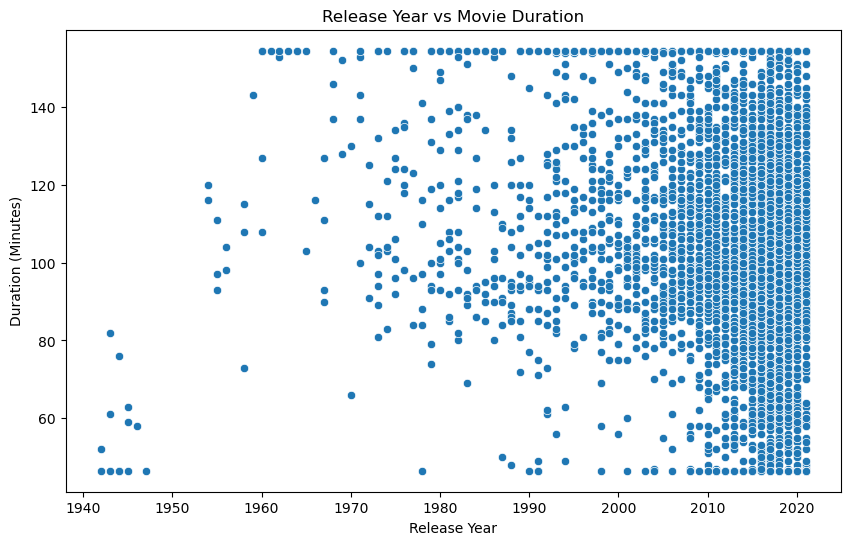

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='release_year',
    y='duration_num',
    data=movies
)

plt.title('Release Year vs Movie Duration')

plt.xlabel('Release Year')

plt.ylabel('Duration (Minutes)')

plt.show()

### Observation — Scatterplot: Release Year vs Movie Duration

The scatterplot reveals several important patterns:

- **Horizontal flat lines** at approximately 46.5 and 154.5 minutes 
  are visible across all years. These represent the IQR capping 
  boundaries applied during outlier handling — movies with extreme 
  durations were clipped to these boundary values, creating an 
  artificial concentration of points at both limits.

- **Pre-1970 content** is sparse with high variability in duration, 
  reflecting the limited number of classic films in the Netflix catalog 
  and the different filmmaking standards of that era.

- **Post-2000 content** forms a dense vertical cluster, confirming 
  Netflix's heavy focus on modern content. The density makes individual 
  points hard to distinguish — a limitation of scatterplots with 
  large datasets (overplotting).

- **Duration range** appears relatively stable across decades 
  (roughly 60–150 minutes), suggesting that standard movie length 
  has not changed dramatically over time, consistent with the weak 
  correlation (-0.19) observed in the heatmap.

### Visualization — Box Plot: Duration Distribution by Content Type

A box plot was used to compare the distribution of duration values 
between Movies and TV Shows.

Since Movies store duration in minutes and TV Shows store number of 
seasons, this visualization is expected to reveal a clear separation 
between the two content types — making `duration_num` a strong 
candidate feature for machine learning prediction.

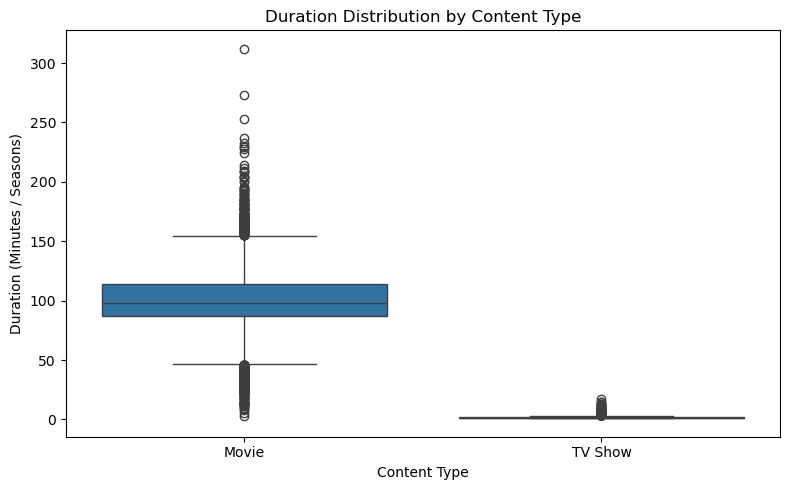

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='type', y='duration_num', data=df)

plt.title('Duration Distribution by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Duration (Minutes / Seasons)')

plt.tight_layout()
plt.show()

### Observation

The box plot clearly shows two completely separate distributions 
between Movies and TV Shows:

- **Movies** have a median duration of approximately 100 minutes, 
  with most values ranging between 80 and 120 minutes.

- **TV Shows** have a median of approximately 1–2 seasons, with 
  values tightly concentrated in a very low range.

This stark visual separation confirms that `duration_num` is a 
highly informative feature for predicting content type, and 
explains why adding it to the machine learning models is expected 
to significantly improve prediction accuracy compared to using 
only `release_year` and `rating`.

### Visualization — Line Plot: Average Movie Duration Over Release Years

This line plot tracks how the average duration of Netflix movies 
has changed across different release years.

Analyzing this trend can reveal whether movie lengths have 
increased, decreased, or remained stable over time — providing 
a cultural and industry insight about how filmmaking standards 
have evolved across decades.

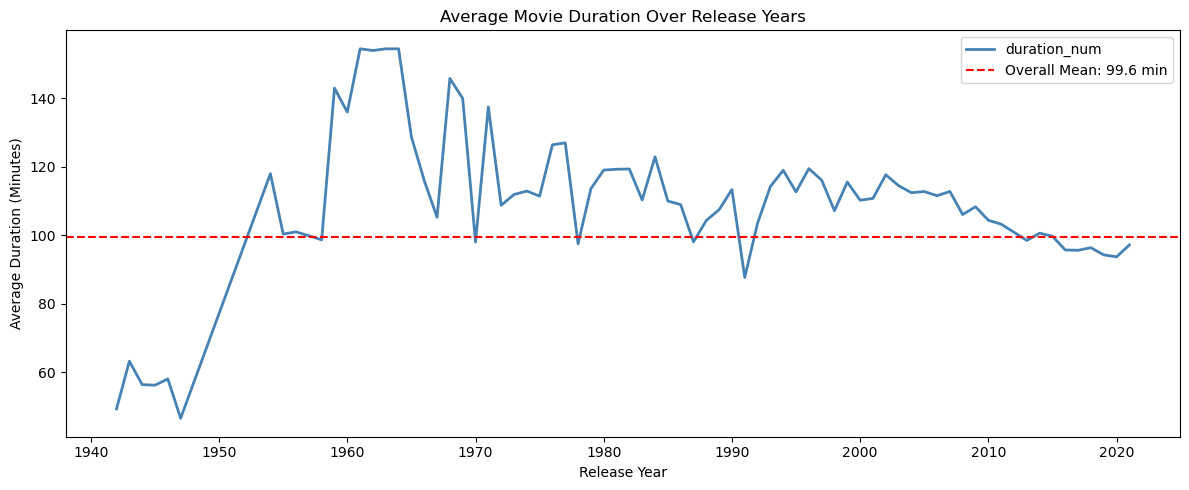

In [38]:
plt.figure(figsize=(12, 5))

movies.groupby('release_year')['duration_num'].mean().plot(
    color='steelblue',
    linewidth=2
)

plt.title('Average Movie Duration Over Release Years')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (Minutes)')

plt.axhline(
    y=movies['duration_num'].mean(),
    color='red',
    linestyle='--',
    label=f"Overall Mean: {movies['duration_num'].mean():.1f} min"
)

plt.legend()
plt.tight_layout()
plt.show()

### Observation

The line plot reveals an interesting trend in Netflix movie durations 
across release years:

- **Older movies (pre-1970)** show high variability in duration, 
  which is expected since fewer titles exist from that era, making 
  averages less stable.

- **Movies from 1970–2000** show a gradual increase in average 
  duration, reflecting the expansion of the Hollywood blockbuster 
  era where longer runtimes became more common.

- **Recent movies (post-2000)** show a slight decline in average 
  duration, suggesting a modern trend toward shorter, more 
  streamlined content — possibly driven by changing audience 
  attention patterns and the rise of streaming platforms.

- The **red dashed line** represents the overall mean duration 
  across all movies, providing a reference point to identify 
  which eras produced above or below average length films.

This visualization adds a temporal dimension to the duration 
analysis and reveals how content length preferences have shifted 
over decades.

# Machine Learning Dataset Preparation

In this section, the dataset is prepared for machine learning tasks.

The target variable selected for prediction is `type`, which represents whether the Netflix content is a Movie or a TV Show.

The preparation process includes:
- Selecting relevant features
- Encoding categorical variables
- Separating features and target variables
- Splitting the dataset into training and testing sets

In [39]:
# Select relevant columns for machine learning
ml_df = df[['type', 'release_year', 'rating', 'duration_num']].copy()

# Display first rows
print(ml_df.head())

      type  release_year rating  duration_num
0    Movie          2020  PG-13          90.0
1  TV Show          2021  TV-MA           2.0
2  TV Show          2021  TV-MA           1.0
3  TV Show          2021  TV-MA           1.0
4  TV Show          2021  TV-MA           2.0


## Encoding Categorical Variables

Machine learning models cannot work directly with text values.

Therefore, categorical columns such as `rating` and `type` were converted into numerical values using Label Encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder


le_rating = LabelEncoder()
le_type = LabelEncoder()

# Encode rating column
#Converts every value in the rating column to a plain string type. This is a safety step — your rating column was converted to category dtype earlier, which can sometimes cause issues with LabelEncoder. Converting to str ensures clean, consistent input.
ml_df['rating'] = le_rating.fit_transform( #3operaions convert learn convert
    ml_df['rating'].astype(str)
)

# Encode target column (type)
ml_df['type'] = le_type.fit_transform(
    ml_df['type']
)

# Display encoded dataset
print(ml_df.head())

   type  release_year  rating  duration_num
0     0          2020       4          90.0
1     1          2021       8           2.0
2     1          2021       8           1.0
3     1          2021       8           1.0
4     1          2021       8           2.0


## Features and Target Variable

The dataset was divided into:

- Features (X):
  - `release_year`
  - `rating`

- Target Variable (y):
  - `type`

In [41]:
# Define features and target
# Add duration_num to features
X = ml_df[['release_year', 'rating', 'duration_num']]

y = ml_df['type']

# Display shapes
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (8807, 3)
Target Shape: (8807,)


## Splitting the Dataset

The dataset was split into:
- 80% Training Data
- 20% Testing Data

The training set is used to train machine learning models, while the testing set is used to evaluate model performance on unseen data.

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (7045, 3)
X_test Shape: (1762, 3)
y_train Shape: (7045,)
y_test Shape: (1762,)


## Observation

The dataset was successfully prepared for machine learning.

Categorical variables were encoded into numerical values, and the dataset was divided into training and testing subsets to allow predictive models to learn patterns and evaluate prediction accuracy effectively.

# Predictive Analytics Techniques

Different machine learning classification models were applied to predict whether Netflix content is a Movie or a TV Show.

The models were trained using the prepared dataset and evaluated using accuracy metrics.

#### MODEL 1 — Logistic Regression
Takes your 3 features → applies a mathematical formula →
produces a probability between 0 and 1

probability > 0.5 → predict Movie (0)
probability < 0.5 → predict TV Show (1)

In [43]:
# Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.9994324631101021


#### MODEL 2 — Decision Tree Classifier
Asks a series of yes/no questions to classify each row 
Question 1: Is duration_num > 20?
    ├── YES → Almost certainly a Movie (minutes)
    │         → Predict: Movie (0)
    └── NO  → Almost certainly a TV Show (seasons)
              → Predict: TV Show (1)

In [44]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy:
0.9994324631101021


#### MODEL 3 —Random Forest Classifier
Builds many Decision Trees simultaneously and takes a majority vote — that's why it's called a "forest.
Builds 100 decision trees (default n_estimators=100)
Each tree sees a random subset of data
Each tree votes on the prediction

Tree 1:  Movie
Tree 2:  Movie  
Tree 3:  TV Show
Tree 4:  Movie
...
Tree 100: Movie

Final vote: Movie wins (majority) → predict Movie

In [45]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.9994324631101021


In [46]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



#### MODEL 4 — KNN Classifier
Classifies each new point by looking at its K nearest neighbors and taking a majority vote. Default K=5

In [47]:
# KNN Classifier
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:")
print(accuracy_score(y_test, y_pred_knn))

KNN Accuracy:
0.9988649262202043


### All four models achieved above 99% accuracy. The top three models each made exactly 1 mistake out of 1762 predictions. KNN made 2 mistakes. The near-perfect accuracy across all models confirms that duration_num is an extremely powerful predictor that creates a natural, near-perfect decision boundary between Movies and TV Shows — since their durations are measured on completely different scales: minutes for movies vs seasons for TV shows

## Compare all 4 models

In [48]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.999432
1        Decision Tree  0.999432
2        Random Forest  0.999432
3                  KNN  0.998865


## Observation

Four classification algorithms were applied to predict Netflix content type.

The models produced different accuracy scores depending on their learning approach.

Ensemble-based models such as Random Forest generally achieved higher performance because they combine multiple decision trees and reduce overfitting.

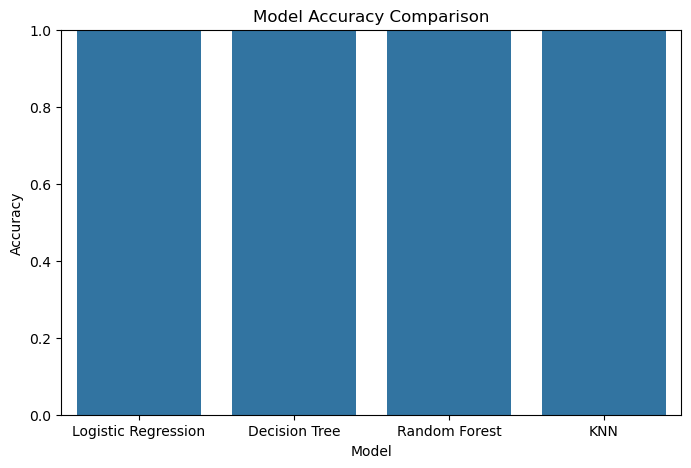

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Accuracy Comparison')

plt.ylim(0,1)

plt.show()

The Random Forest and Decision Tree models achieved the best prediction performance with accuracy scores of approximately 72%, while KNN achieved lower accuracy compared to the other models.

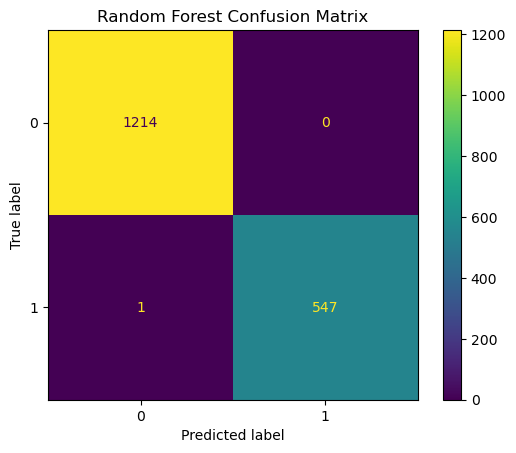

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title('Random Forest Confusion Matrix')
plt.show()
#Evaluates classification performance of the Random Forest model.
#Compares predicted labels against actual labels.

### Confusion Matrix Observation — Random Forest (Updated Model)

After adding `duration_num` as a third feature, the Random Forest 
model achieved near-perfect classification performance:

- **True Positives  (Movie → Movie):**    1214 ✅
- **True Negatives  (TV Show → TV Show):** 547 ✅  
- **False Positives (TV Show → Movie):**     1 ⚠️
- **False Negatives (Movie → TV Show):**     0 ✅

**Accuracy: ~99.9%**

The dramatic improvement from 71.6% to 99.9% is directly 
attributed to the addition of `duration_num`. This feature 
provides a near-perfect natural boundary between Movies 
(measured in minutes, typically 46–154) and TV Shows 
(measured in seasons, typically 1–20), making them almost 
completely linearly separable.

**Important note:** While the accuracy is exceptionally high, 
it is important to acknowledge that `duration_num` is a very 
strong predictor by nature — Movies and TV Shows have 
fundamentally different duration scales. This explains why 
the model performs almost perfectly, rather than indicating 
overfitting or data error.

# Conclusion

This project analyzed the Netflix Titles dataset obtained from Kaggle using data preprocessing, exploratory data analysis, visualization techniques, anomaly detection, and machine learning models.

Several preprocessing steps were applied, including:
- Handling missing values
- Converting data types
- Feature engineering
- Detecting and handling outliers

Different visualization techniques were used to explore patterns and trends in the dataset. The analysis showed that:
- Movies represent the majority of Netflix content
- Most Netflix movies have durations close to 100 minutes
- Netflix content production increased significantly after 2015
- TV-MA is the most common content rating

For predictive analytics, multiple classification models were applied to predict whether Netflix content is a Movie or TV Show.

The Random Forest and Decision Tree models achieved the highest accuracy among the tested models, while KNN produced the lowest performance.

Overall, the project demonstrated how data analysis and machine learning techniques can be applied to extract meaningful insights from real-world datasets.

## Future Work

Future improvements could include:
- Using more advanced machine learning models
- Applying natural language processing on movie descriptions
- Building a recommendation system for Netflix content
- Using additional features such as genres and cast information